# Домашнее задание 3. Модели классификации и нелинейные зависимости

Один банк обратился к вам за помощью: он хочет разработать кампанию лояльности по удержанию клиентов. Для этого он хочет прогнозировать вероятности оттока клиентов и определять, уйдет ли клиент в ближайшее время. Чтобы решить эту задачу, вам предстоит построить модель машинного обучения, которая будет прогнозировать этот отток клиентов.

Технически необходимо построить классификатор, который позволит своевременно определять уходящих клиентов банка, оценить качество построенных моделей и проинтерпретировать результаты.

---

### Описание данных

| Признак | Описание |
| ------ | -------- |
| `RowNumber` | номер строки таблицы |
| `CustomerId` | идентификатор клиента |
| `Surname` | фамилия клиента |
| `CreditScore` | кредитный рейтинг клиента |
| `Geography` | страна проживания клиента |
| `Gender` | пол клиента |
| `Age` | возраст клиента |
| `Tenure` | сколько лет клиент пользуется банком |
| `Balance` | сумма средств на счетах клиента |
| `NumOfProduct` | количество банковских продуктов |
| `HasCrCard` | наличие кредитной карты (1 — да, 0 — нет) |
| `IsActiveMember` | активный клиент (1 — да, 0 — нет) |
| `EstimatedSalary` | предполагаемая заработная плата |

**Целевая переменная**

`Exited` — индикатор оттока клиента (1 — ушел, 0 — остался).



In [1]:
# Работа с данными и вычислениями
import numpy as np
import pandas as pd

# Визуализация
import matplotlib.pyplot as plt
import seaborn as sns

# Машинное обучение
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

## Часть I. Знакомство и анализ

В этой части вам предстоит провести первичный анализ данных. Выполним ряд проверок и при необходимости почистим данные.

### Задание 1.1

**Проверим данные на полноту и качество.**  
- Проверьте наличие пропусков в данных и при необходимости обработайте их.  
- Проверьте наличие выбросов и при необходимости почистите их.
- Проверьте наличие дубликатов и при необходимости почистите их.
- Подумайте, есть ли в данных неинформативные признаки, при необходимости удалите их.
- Не забудьте записать наблюдения в виде небольшого вывода.

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/ivanchiginev3/MIPT-Machine-Learning-Homeworks/refs/heads/main/HW_3/bank_clients.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
1,16,15643966,Goforth,616,Germany,Male,45,3,143129.41,2,0,1,64327.26,0
2,17,15737452,Romeo,653,Germany,Male,58,1,132602.88,1,1,0,5097.67,1
3,27,15736816,Young,756,Germany,Male,36,2,136815.64,1,1,1,170041.95,0
4,29,15728693,McWilliams,574,Germany,Female,43,3,141349.43,1,1,1,100187.43,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2509 entries, 0 to 2508
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        2509 non-null   int64  
 1   CustomerId       2509 non-null   int64  
 2   Surname          2509 non-null   object 
 3   CreditScore      2509 non-null   int64  
 4   Geography        2509 non-null   object 
 5   Gender           2509 non-null   object 
 6   Age              2509 non-null   int64  
 7   Tenure           2509 non-null   int64  
 8   Balance          2509 non-null   float64
 9   NumOfProducts    2509 non-null   int64  
 10  HasCrCard        2509 non-null   int64  
 11  IsActiveMember   2509 non-null   int64  
 12  EstimatedSalary  2509 non-null   float64
 13  Exited           2509 non-null   int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 274.6+ KB


In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
1,16,15643966,Goforth,616,Germany,Male,45,3,143129.41,2,0,1,64327.26,0
2,17,15737452,Romeo,653,Germany,Male,58,1,132602.88,1,1,0,5097.67,1
3,27,15736816,Young,756,Germany,Male,36,2,136815.64,1,1,1,170041.95,0
4,29,15728693,McWilliams,574,Germany,Female,43,3,141349.43,1,1,1,100187.43,0


In [6]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,2509.000000,2.509000e+03,2509.000000,2509.000000,2509.000000,2509.000000,2509.000000,2509.00000,2509.000000,2509.000000,2509.000000
mean,5000.278996,1.569056e+07,651.453567,39.771622,5.009964,119730.116134,1.519729,0.71383,0.497409,101113.435102,0.324432
std,2918.980192,7.322843e+04,98.168937,10.519143,2.935154,27022.006157,0.619420,0.45206,0.500093,58263.011501,0.468256
min,8.000000,1.556578e+07,350.000000,18.000000,0.000000,27288.430000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2461.000000,1.562740e+07,584.000000,32.000000,2.000000,102800.720000,1.000000,0.00000,0.000000,51016.020000,0.000000
50%,4997.000000,1.568989e+07,651.000000,38.000000,5.000000,119703.100000,1.000000,1.00000,0.000000,102397.220000,0.000000
75%,7583.000000,1.575573e+07,722.000000,45.000000,8.000000,137560.380000,2.000000,1.00000,1.000000,151083.800000,1.000000
max,9999.000000,1.581566e+07,850.000000,84.000000,10.000000,214346.960000,4.000000,1.00000,1.000000,199970.740000,1.000000


In [7]:
df.describe(include=['object'])

,Surname,Geography,Gender
count,2509,2509,2509
unique,1330,1,2
top,Martin,Germany,Male
freq,11,2509,1316


In [8]:
df = df.drop(['RowNumber', 'CustomerId', 'Surname', 'Geography'], axis=1)

In [9]:
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,376,Female,29,4,115046.74,4,1,0,119346.88,1
1,616,Male,45,3,143129.41,2,0,1,64327.26,0
2,653,Male,58,1,132602.88,1,1,0,5097.67,1
3,756,Male,36,2,136815.64,1,1,1,170041.95,0
4,574,Female,43,3,141349.43,1,1,1,100187.43,0


**Вывод:** Удалили несколько неинформативных признаков: `RowNumber`, `CustomerId`, `Surname`, `Geography`. В остальном с данными можно работать дальше

### Задание 1.2

**Проверим распределения:**  
- Посмотрите на распределение целевого признака `Exited`.
- Изучите распределения остальных признаков, а также парные зависимости (можете воспользоваться `pairplot`).
- Зафиксируйте наблюдения в небольшом выводе.

<Axes: xlabel='Exited', ylabel='count'>

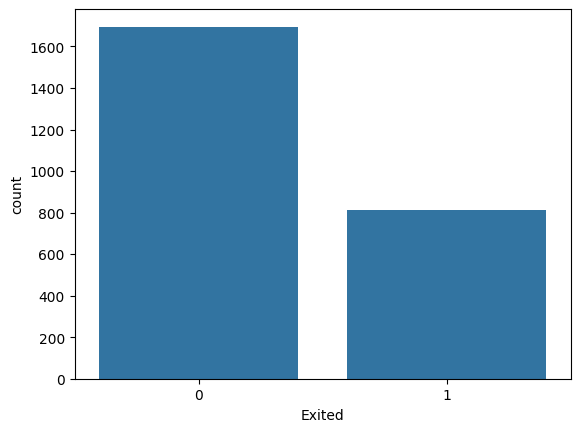

In [10]:
sns.countplot(data=df, x = 'Exited')

In [11]:
num_df = df.drop('Gender', axis=1)

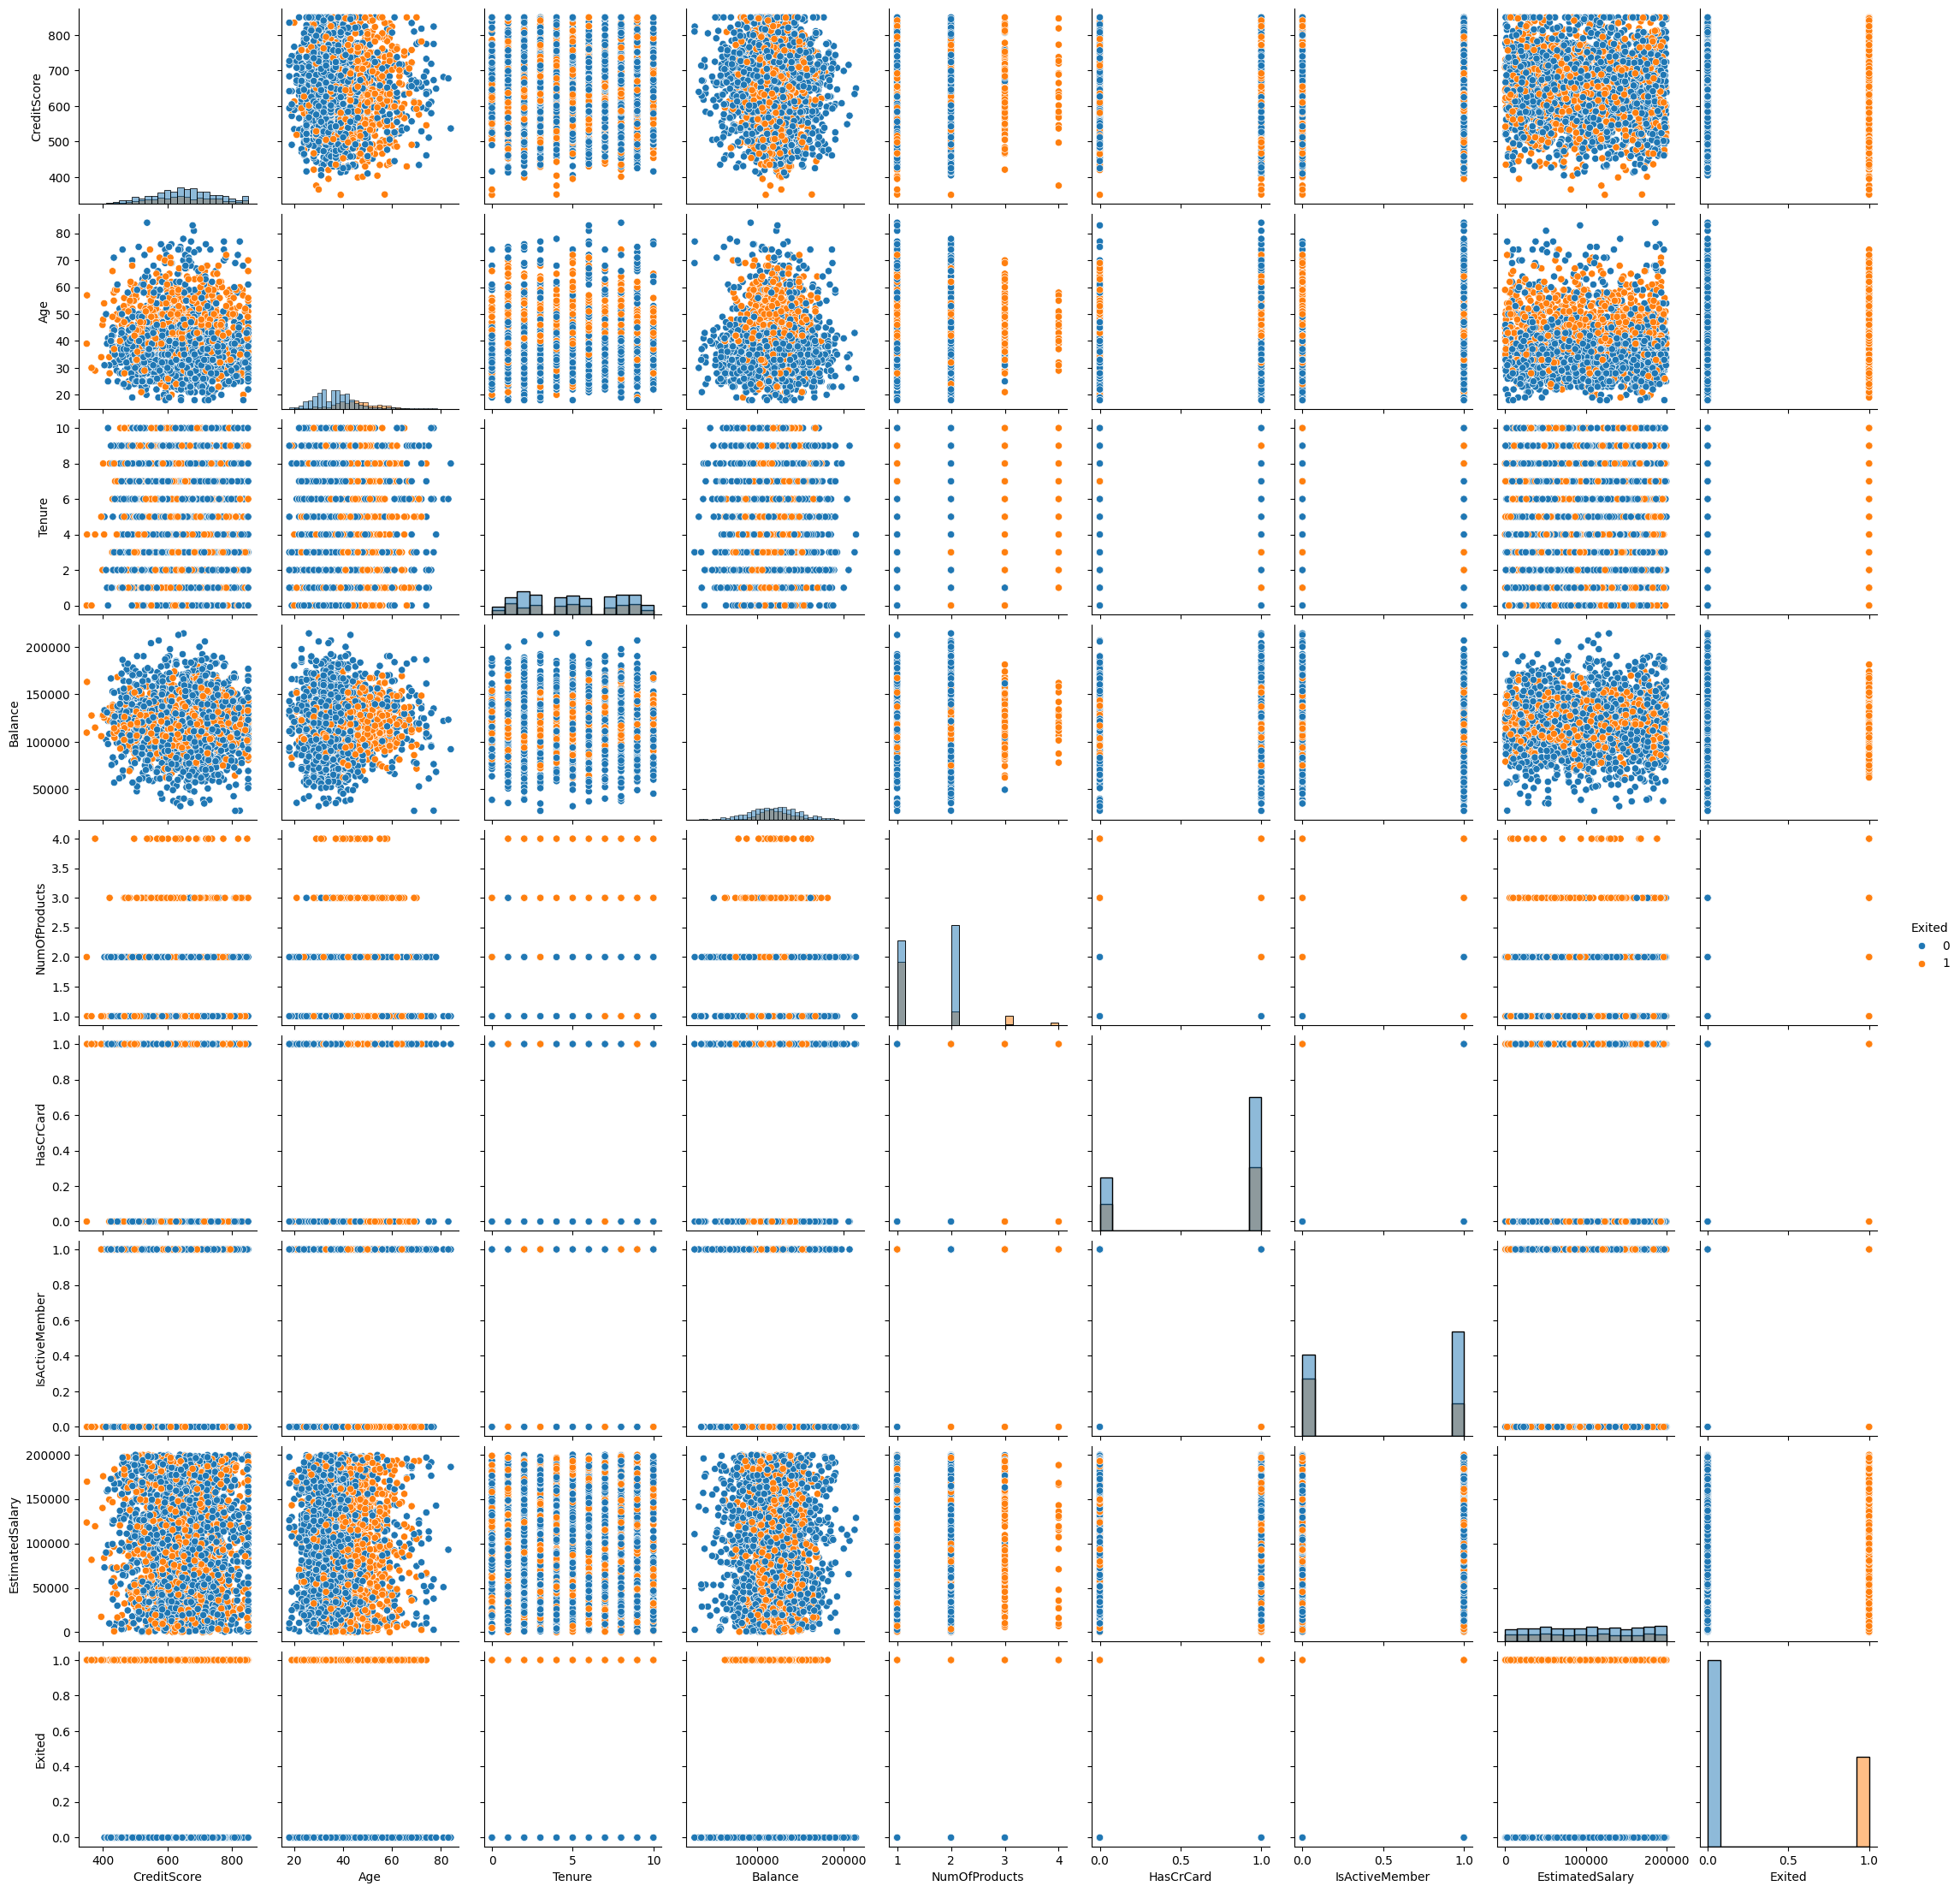

In [12]:
sns.pairplot(
    df,
    vars= num_df.columns,
    hue="Exited",
    diag_kind="hist"
)
plt.show()

**Вывод:** Видно что в таргете есть дисбаланс

### Задание 1.3

**Проверим мультиколлинеарность:**  
- Постройте матрицу корреляций и визуализируйте ее.  
- Проанализируйте наличие мультиколлинеарных признаков (в качестве порога можно взять ±0.7) и удалите ненужные при необходимости.
- Отразите наблюдения в небольшом выводе.

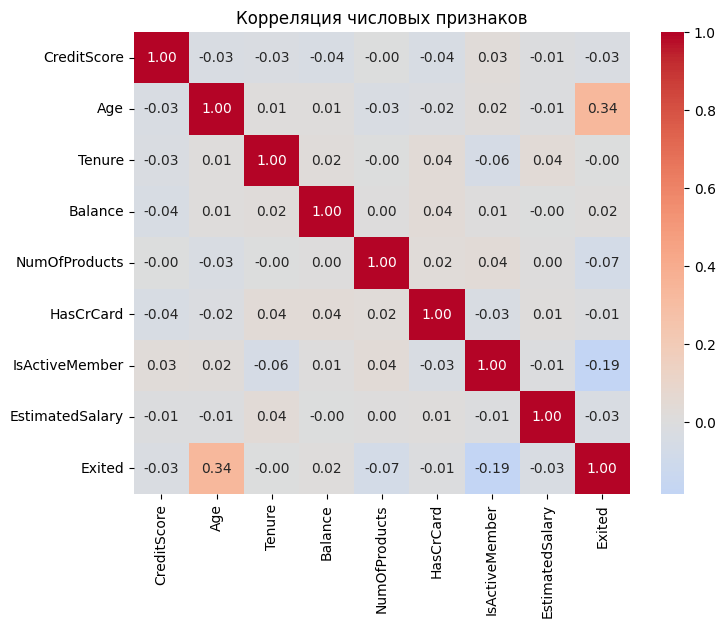

In [13]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    num_df.corr(),
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)
plt.title("Корреляция числовых признаков")
plt.show()

**Вывод:** Мультиколлинераные признаки отсутсвуют

### Задание 1.4

**Расширим датасет с помощью методов Feature Engineering:**
* `BalanceSalaryRatio` — отношение баланса на счетах к заработной плате клиента;
* `TenureByAge` — отношение времени пользования услугами банка к возрасту клиента;
* `CreditScoreGivenAge` — отношение кредитного рейтинга к возрасту клиента.

In [14]:
df['BalanceSalaryRatio'] = df['Balance'] / df['EstimatedSalary']

In [15]:
df['TenureByAge'] = df['Tenure'] / df['Age']

In [16]:
df['CreditScoreGivenAge'] = df['CreditScore'] / df['Age']

### Задание 1.5

**Закодируем категориальные признаки:**
* Для начала выберите признаки для кодирования.
* Затем подберите к каждому подходящий способ — закодируйте и сформируйте единый датафрейм.
* Обоснуйте в небольшом выводе, почему выбрали тот или иной способ.

In [17]:
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

In [18]:
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalanceSalaryRatio,TenureByAge,CreditScoreGivenAge
0,376,1,29,4,115046.74,4,1,0,119346.88,1,0.963969,0.137931,12.965517
1,616,0,45,3,143129.41,2,0,1,64327.26,0,2.225020,0.066667,13.688889
2,653,0,58,1,132602.88,1,1,0,5097.67,1,26.012449,0.017241,11.258621
3,756,0,36,2,136815.64,1,1,1,170041.95,0,0.804599,0.055556,21.000000
4,574,1,43,3,141349.43,1,1,1,100187.43,0,1.410850,0.069767,13.348837


**Вывод:** У нас только один признак требует кодировки. Это `Gender` и он бинарный, поэтом кодируем 0 или 1

### Задание 1.6

**Разделим на тренировочную и тестовую выборки:**
* Установите соотношение 80/20, `random_state=42` и учитывайте дисбаланс при его наличии.

In [19]:
X = df.drop('Exited', axis=1)
y = df['Exited']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Задание 1.7

**Выполним масштабирование/нормализацию:**
* Выберите подходящий способ масштабирования или нормализации данных.
* Примените его для обучающей и тестовой выборки.
* Обоснуйте в небольшом выводе, почему выбрали тот или иной способ.

In [20]:
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

In [21]:
normal_features = ['CreditScore', 'Age', 'Tenure', 'Balance',
                   'TenureByAge', 'CreditScoreGivenAge']

scaler= StandardScaler()
X_train_scaled[normal_features] = scaler.fit_transform(X_train[normal_features])
X_test_scaled[normal_features] = scaler.transform(X_test[normal_features])

In [22]:
X_train_scaled['BalanceSalaryRatio'] = np.log1p(X_train['BalanceSalaryRatio'])
X_test_scaled['BalanceSalaryRatio'] = np.log1p(X_test['BalanceSalaryRatio'])

In [23]:
scaler = StandardScaler()
X_train_scaled['BalanceSalaryRatio'] = scaler.fit_transform(X_train_scaled[['BalanceSalaryRatio']])
X_test_scaled['BalanceSalaryRatio'] = scaler.transform(X_test_scaled[['BalanceSalaryRatio']])

In [24]:
scaler = RobustScaler()
X_train_scaled['EstimatedSalary'] = scaler.fit_transform(X_train[['EstimatedSalary']])
X_test_scaled['EstimatedSalary'] = scaler.transform(X_test[['EstimatedSalary']])

In [25]:
scaler = MinMaxScaler()
X_train_scaled['NumOfProducts'] = scaler.fit_transform(X_train[['NumOfProducts']])
X_test_scaled['NumOfProducts'] = scaler.transform(X_test[['NumOfProducts']])

In [26]:
X_train_scaled.describe()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,BalanceSalaryRatio,TenureByAge,CreditScoreGivenAge
count,2.007000e+03,2007.000000,2.007000e+03,2.007000e+03,2.007000e+03,2007.000000,2007.000000,2007.000000,2007.000000,2.007000e+03,2.007000e+03,2.007000e+03
mean,-7.788710e-17,0.473343,-6.505343e-17,-1.814415e-17,1.053246e-16,0.174722,0.714998,0.490284,-0.007805,1.283367e-16,-2.084365e-16,1.354173e-16
std,1.000249e+00,0.499413,1.000249e+00,1.000249e+00,1.000249e+00,0.207932,0.451528,0.500030,0.583301,1.000249e+00,1.000249e+00,1.000249e+00
min,-3.047353e+00,0.000000,-2.083915e+00,-1.717124e+00,-3.404134e+00,0.000000,0.000000,0.000000,-1.009609,-1.111085e+00,-1.546344e+00,-2.123887e+00
25%,-6.855939e-01,0.000000,-7.419834e-01,-1.032730e+00,-6.211125e-01,0.000000,0.000000,0.000000,-0.511643,-5.996932e-01,-8.258943e-01,-7.104252e-01
50%,-9.363797e-03,0.000000,-1.668699e-01,-6.138066e-03,-5.541189e-03,0.000000,1.000000,0.000000,0.000000,-3.322064e-01,-1.054442e-01,-1.280059e-01
75%,7.274242e-01,1.000000,5.040960e-01,1.020454e+00,6.577981e-01,0.333333,1.000000,1.000000,0.488357,2.266302e-01,7.590960e-01,6.227491e-01
max,1.999141e+00,1.000000,4.146482e+00,1.704848e+00,3.506788e+00,1.000000,1.000000,1.000000,0.985903,1.044105e+01,4.217256e+00,5.383409e+00


**Вывод:** Бинарные признаки (`Gender`, `HasCrCard`, `IsActiveMember`) — не масштабируем, так как уже имеют формат 0/1.

`CreditScore`, `Age`, `Tenure`, `Balance`, `TenureByAge`, `CreditScoreGivenAge` — StandardScaler, потому что распределение близко к нормальному, выбросов нет.

`EstimatedSalary` — RobustScaler из-за наличия выбросов в данных о зарплате.

`NumOfProducts` — MinMaxScaler, так как признак имеет всего 4 значения и нужно сохранить порядок.

`BalanceSalaryRatio` — логарифмирование + StandardScaler, чтобы сжать экстремально большой разброс значений.

## Часть II. Линейные модели

Приступаем к моделированию. В этой части построим baseline — простейшее решение, от которого будем отталкиваться. Вдруг базовая логистическая регрессия уже будет приемлема по качеству, и необходимости в сложных моделях не будет?


### Задание 2.1

**Для начала определим метрику, на которую будем ориентироваться.**

По условию задачи, наша модель должна своевременно предсказывать отток клиентов. Известно, что для сохранения клиентов банк будет использовать ресурсы кол-центра, и клиентам, у которых вероятность оттока наиболее высока, будут сделаны специальные предложения. Ресурсы, выделяемые на сохранение клиентов, ограничены, поэтому нам важно минимизировать количество звонков. Однако в то же время необходимо сохранить как можно больше клиентов.

Таким образом, нам бы хотелось минимизировать как ложноположительные и ложноотрицательные срабатывания модели.

* Какую метрику в данной задаче вы будете пытаться улучшить? Обоснуйте свой выбор.

**Ответ:** Мы будем улучшать F1-меру, так как она одновременно учитывает точность (Precision) и полноту (Recall). Это важно, поскольку нам нужно минимизировать и лишние звонки (ложные срабатывания), и потерю клиентов (пропущенные оттоки). Accuracy не подходит из-за дисбаланса классов, а по отдельности Precision или Recall дают однобокую оценку.

### Задание 2.2

**Обучите модель логистической регрессии:**
* Реализуйте алгоритм вручную и сравните с `LogisticRegression` из sklearn по коэффициентам и метрикам (подробнее п.3).
* Позаботьтесь о воспроизводимости результата, установив конкретное значение гиперпараметра `random_state` (например, число 42).
* Сделайте предсказание меток классов для тренировочной и тестовой выборок. Рассчитайте значение целевой метрики на обеих выборках. Также выберите метрику, которая не зависит от порога — она будет удобна для сравнения разных моделей между собой. Рассчитайте также ее значение на обеих выборках для всех моделей.
* Проинтерпретируйте полученные результаты, ответив на вопрос: «Является ли модель переобученной или недообученной?»
* Определите, какие признаки, по мнению модели, наиболее важные, сопоставив их со значениями весов.

> **Примечание.** Будем считать, что модель нас не удовлетворяет (считается недообученной), если значение целевой метрики на тестовой выборке меньше 0.5.

**Дополнительное задание:**

Попробуйте поуправлять следующими гиперпараметрами модели в sklearn:
* `penalty` — тип используемой регуляризации ('l1' — $L_1$-регуляризация, 'l2' — $L_2$-регуляризация);
* `C` — коэффициент, обратный коэффициенту регуляризации (по умолчанию он равен 1).

Понаблюдайте, как ведут себя метрики в зависимости от типа регуляризации и увеличения/уменьшения значения гиперпараметра `C`.

In [27]:
class ManualLogistic:
    def __init__(self, lr=0.1, n_iter=1000):
        self.lr = lr
        self.n_iter = n_iter

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        self.b = 0
        for _ in range(self.n_iter):
            z = np.dot(X, self.w) + self.b
            h = self.sigmoid(z)
            grad_w = np.dot(X.T, (h - y)) / y.size
            grad_b = np.mean(h - y)
            self.w -= self.lr * grad_w
            self.b -= self.lr * grad_b

    def predict(self, X):
        return (self.sigmoid(np.dot(X, self.w) + self.b) >= 0.5).astype(int)

    def predict_proba(self, X):
        return self.sigmoid(np.dot(X, self.w) + self.b)

In [28]:
def print_metrics(y_true, y_pred, y_proba):
    """
    Печатает основные метрики классификации
    """
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"F1-score:  {f1_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"ROC-AUC:   {roc_auc_score(y_true, y_proba):.4f}")

In [29]:
model = ManualLogistic(lr=0.01, n_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred_train = model.predict(X_train_scaled)
y_proba_train = model.predict_proba(X_train_scaled)
y_pred_test = model.predict(X_test_scaled)
y_proba_test = model.predict_proba(X_test_scaled)

print('Метрики на трейне')
print_metrics(y_train, y_pred_train, y_proba_train)
print('------------------------------')
print('Метрики на тесте')
print_metrics(y_test, y_pred_test, y_proba_test)

Метрики на трейне
Accuracy:  0.7374
Precision: 0.6703
Recall:    0.3748
F1-score:  0.4808
ROC-AUC:   0.7621
------------------------------
Метрики на тесте
Accuracy:  0.6892
Precision: 0.5412
Recall:    0.2822
F1-score:  0.3710
ROC-AUC:   0.6996


In [30]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred_train = model.predict(X_train_scaled)
y_proba_train = model.predict_proba(X_train_scaled)[:, 1]
y_pred_test = model.predict(X_test_scaled)
y_proba_test = model.predict_proba(X_test_scaled)[:, 1]

print('Метрики на трейне')
print_metrics(y_train, y_pred_train, y_proba_train)
print('------------------------------')
print('Метрики на тесте')
print_metrics(y_test, y_pred_test, y_proba_test)

Метрики на трейне
Accuracy:  0.7409
Precision: 0.6403
Recall:    0.4593
F1-score:  0.5349
ROC-AUC:   0.7695
------------------------------
Метрики на тесте
Accuracy:  0.7012
Precision: 0.5586
Recall:    0.3804
F1-score:  0.4526
ROC-AUC:   0.7067


In [31]:
importance = pd.DataFrame({
    'Признак': X_train.columns,
    'Коэффициент': model.coef_[0],
    'Модуль': np.abs(model.coef_[0])
}).sort_values('Модуль', ascending=False)

print(importance[['Признак', 'Коэффициент']].to_string(index=False))

            Признак  Коэффициент
CreditScoreGivenAge    -1.098039
     IsActiveMember    -0.996058
      NumOfProducts    -0.554959
        CreditScore     0.450539
             Gender     0.390779
        TenureByAge    -0.261177
             Tenure     0.205409
    EstimatedSalary    -0.092418
 BalanceSalaryRatio     0.063280
            Balance     0.045638
          HasCrCard     0.001072
                Age     0.000716


**Вывод:** Обе модели недообучены, так как F1 на тесте < 0.5. Самые важные признаки:
- `CreditScoreGivenAge`
- `IsActiveMember`
- `NumOfProducts`

## Часть III. Нелинейные алгоритмы

Приступаем к тяжелой артиллерии — нелинейным алгоритмам. Попробуем улучшить предсказания baseline.

### Задание 3.1

**Обучите логистическую регрессию на полиномиальных признаках:**
* Реализуйте класс добавления полиномиальных фичей степени 2 вручную, обучите на модифицированном датасете любую модель логистической регрессии из предыдущих. Сравните с `PolynomialFeatures` из `sklearn`.
* Позаботьтесь о воспроизводимости результатов, установив конкретное  значение `random_state` (например, число 42).
* Сделайте предсказания для тренировочной и тестовой выборок. Аналогично рассчитайте значение целевой метрики на каждой из выборок и той, которая не зависит от порога для обоих подходов с полиномиальными фичами.
* Не забудьте о масштабировании.
* Посмотрите на коэффициенты модели.
* Сделайте вывод, сравнив результат с baseline.

In [32]:
class PolynomialFeatures2:
    """
    Генератор полиномиальных фичей степени 2
    """

    def fit(self, X):
        self.n_features_ = X.shape[1]
        return self

    def transform(self, X):
        X = np.array(X)
        n_samples = X.shape[0]
        poly_features = [X]

        poly_features.append(X ** 2)

        for i in range(self.n_features_):
            for j in range(i + 1, self.n_features_):
                poly_features.append((X[:, i] * X[:, j]).reshape(n_samples, 1))

        return np.hstack(poly_features)

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

In [33]:
poly = PolynomialFeatures2()
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

In [34]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_poly, y_train)

y_pred_train = model.predict(X_train_poly)
y_proba_train = model.predict_proba(X_train_poly)[:, 1]
y_pred_test = model.predict(X_test_poly)
y_proba_test = model.predict_proba(X_test_poly)[:, 1]

print('Метрики на трейне')
print_metrics(y_train, y_pred_train, y_proba_train)
print('------------------------------')
print('Метрики на тесте')
print_metrics(y_test, y_pred_test, y_proba_test)

Метрики на трейне
Accuracy:  0.8127
Precision: 0.7723
Recall:    0.5991
F1-score:  0.6747
ROC-AUC:   0.8665
------------------------------
Метрики на тесте
Accuracy:  0.7570
Precision: 0.6694
Recall:    0.4969
F1-score:  0.5704
ROC-AUC:   0.7993


In [35]:
poly = PolynomialFeatures(degree=2, include_bias=False)

poly.fit(X_train_scaled)

X_train_poly = poly.transform(X_train_scaled)

X_test_poly = poly.transform(X_test_scaled)

In [36]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_poly, y_train)

y_pred_train = model.predict(X_train_poly)
y_proba_train = model.predict_proba(X_train_poly)[:, 1]
y_pred_test = model.predict(X_test_poly)
y_proba_test = model.predict_proba(X_test_poly)[:, 1]
coeff = model.coef_[0]

print('Метрики на трейне')
print_metrics(y_train, y_pred_train, y_proba_train)
print('------------------------------')
print('Метрики на тесте')
print_metrics(y_test, y_pred_test, y_proba_test)
print('------------------------------')
print('Коэффициенты:')
print(coeff)

Метрики на трейне
Accuracy:  0.8127
Precision: 0.7723
Recall:    0.5991
F1-score:  0.6747
ROC-AUC:   0.8665
------------------------------
Метрики на тесте
Accuracy:  0.7570
Precision: 0.6694
Recall:    0.4969
F1-score:  0.5704
ROC-AUC:   0.7993
------------------------------
Коэффициенты:
[ 0.11598817  0.18493172  0.93820728  0.02796862  0.17281069 -3.57141766
  0.05287618 -0.53624837 -0.30322757 -0.04738899 -0.18870194 -0.32607474
  0.12741594 -0.10653394  0.2399864   0.20620755  0.05356485 -0.21287971
  0.13091032  0.69018686 -0.10978037 -0.16333391  0.10466891 -0.01258487
  0.18493172  0.12559459  0.14490181 -0.05008916 -0.25777487 -0.19126951
  0.4736317   0.01654179  0.06328802 -0.02899302  0.25104953 -1.02333396
  0.03606158  0.05398199 -0.08014991 -0.40084136 -1.17910749 -0.03365124
 -0.1796301  -0.62961521 -1.59496998  0.43938343  0.2787736   0.00938201
  0.04474408 -0.42458779  0.05925296  0.3301742  -0.11571485 -0.05597615
 -0.55633471 -0.19126794  0.09996861 -0.07099871 -0.

**Вывод:** Полиномиальная модель второй степени показала значительное улучшение по сравнению с базовой линейной моделью:

- F1-мера выросла с 0.45 до 0.57
- ROC-AUC вырос с 0.71 до 0.80
- Recall вырос с 0.38 до 0.50

Это означает, что добавление полиномиальных признаков позволило модели уловить нелинейные зависимости, которые были невидны для простой линейной модели. Модель стала сложнее, но при этом лучше обобщает на тестовых данных.

### Задание 3.2

**Обучите на тренировочной выборке метод опорных векторов `SVM`:**
* Позаботьтесь о воспроизводимости результатов, установив конкретное  значение `random_state` (например, число 42).
* Поэкспериментируйте с различными типами ядер и выберите наилучшее (гиперпараметр `kernel`)
* Сделайте предсказания для тренировочной и тестовой выборок. Также рассчитайте значение целевой метрики и не зависящей от порога на каждой из выборок.
* Посмотрите на коэффициенты модели.
* Сделайте вывод, сравнив результат с полученными ранее.

**Дополнительное задание:**

Попробуйте поуправлять следующими гиперпараметрами модели:
* `C` — коэффициент, обратный коэффициенту регуляризации;
* `class_weight` — веса классов.

Понаблюдайте, как изменяются значения метрик при увеличении или уменьшении гиперпараметра `C`, а также при учёте дисбаланса классов.

In [37]:
model = SVC(kernel='linear', random_state=42, probability=True)
model.fit(X_train_scaled, y_train)

y_pred_train = model.predict(X_train_scaled)
y_proba_train = model.predict_proba(X_train_scaled)[:, 1]
y_pred_test = model.predict(X_test_scaled)
y_proba_test = model.predict_proba(X_test_scaled)[:, 1]
coeff = model.coef_[0]

print('Метрики на трейне')
print_metrics(y_train, y_pred_train, y_proba_train)
print('------------------------------')
print('Метрики на тесте')
print_metrics(y_test, y_pred_test, y_proba_test)
print('------------------------------')
print('Коэффициенты:')
print(coeff)

Метрики на трейне
Accuracy:  0.7434
Precision: 0.6753
Recall:    0.4025
F1-score:  0.5043
ROC-AUC:   0.7676
------------------------------
Метрики на тесте
Accuracy:  0.6992
Precision: 0.5667
Recall:    0.3129
F1-score:  0.4032
ROC-AUC:   0.7090
------------------------------
Коэффициенты:
[-0.04659177  0.23985697  0.87983003 -0.16961869  0.01790096 -0.56036321
  0.04976173 -0.61155704 -0.0434528   0.05097187  0.16837045  0.04563664]


In [38]:
model = SVC(kernel='poly', degree=2, random_state=42, probability=True)
model.fit(X_train_scaled, y_train)

y_pred_train = model.predict(X_train_scaled)
y_proba_train = model.predict_proba(X_train_scaled)[:, 1]
y_pred_test = model.predict(X_test_scaled)
y_proba_test = model.predict_proba(X_test_scaled)[:, 1]

print('Метрики на трейне')
print_metrics(y_train, y_pred_train, y_proba_train)
print('------------------------------')
print('Метрики на тесте')
print_metrics(y_test, y_pred_test, y_proba_test)

Метрики на трейне
Accuracy:  0.7673
Precision: 0.7644
Recall:    0.4086
F1-score:  0.5325
ROC-AUC:   0.8046
------------------------------
Метрики на тесте
Accuracy:  0.7052
Precision: 0.5926
Recall:    0.2945
F1-score:  0.3934
ROC-AUC:   0.7216


In [39]:
model = SVC(kernel='rbf', random_state=42, probability=True)
model.fit(X_train_scaled, y_train)

y_pred_train = model.predict(X_train_scaled)
y_proba_train = model.predict_proba(X_train_scaled)[:, 1]
y_pred_test = model.predict(X_test_scaled)
y_proba_test = model.predict_proba(X_test_scaled)[:, 1]

print('Метрики на трейне')
print_metrics(y_train, y_pred_train, y_proba_train)
print('------------------------------')
print('Метрики на тесте')
print_metrics(y_test, y_pred_test, y_proba_test)

Метрики на трейне
Accuracy:  0.8037
Precision: 0.7954
Recall:    0.5315
F1-score:  0.6372
ROC-AUC:   0.8378
------------------------------
Метрики на тесте
Accuracy:  0.7331
Precision: 0.6355
Recall:    0.4172
F1-score:  0.5037
ROC-AUC:   0.7679


In [40]:
model = SVC(kernel='sigmoid', random_state=42, probability=True)
model.fit(X_train_scaled, y_train)

y_pred_train = model.predict(X_train_scaled)
y_proba_train = model.predict_proba(X_train_scaled)[:, 1]
y_pred_test = model.predict(X_test_scaled)
y_proba_test = model.predict_proba(X_test_scaled)[:, 1]

print('Метрики на трейне')
print_metrics(y_train, y_pred_train, y_proba_train)
print('------------------------------')
print('Метрики на тесте')
print_metrics(y_test, y_pred_test, y_proba_test)

Метрики на трейне
Accuracy:  0.6333
Precision: 0.4326
Recall:    0.4194
F1-score:  0.4259
ROC-AUC:   0.6189
------------------------------
Метрики на тесте
Accuracy:  0.6434
Precision: 0.4467
Recall:    0.4110
F1-score:  0.4281
ROC-AUC:   0.6114


Наилучшим ядром оказался rbf с результатом:
- на трейне `ROC-AUC` = 0.8378
- на тесте `ROC-AUC` = 0.7679

In [41]:
model = SVC(kernel='rbf', C = 1, class_weight={0: 1, 1: 3}, random_state=42, probability=True)
model.fit(X_train_scaled, y_train)

y_pred_train = model.predict(X_train_scaled)
y_proba_train = model.predict_proba(X_train_scaled)[:, 1]
y_pred_test = model.predict(X_test_scaled)
y_proba_test = model.predict_proba(X_test_scaled)[:, 1]

print('Метрики на трейне')
print_metrics(y_train, y_pred_train, y_proba_train)
print('------------------------------')
print('Метрики на тесте')
print_metrics(y_test, y_pred_test, y_proba_test)

Метрики на трейне
Accuracy:  0.7359
Precision: 0.5595
Recall:    0.8740
F1-score:  0.6823
ROC-AUC:   0.8596
------------------------------
Метрики на тесте
Accuracy:  0.6653
Precision: 0.4903
Recall:    0.7730
F1-score:  0.6000
ROC-AUC:   0.7719


**Вывод:**
После управления гиперпараметрами модели SVM с rbf ядром можно отметить следующее:
- при увеличении С модель переобучается, что логично так как это обратный коэффициент регуляризации. Оптимальным оказалось значение 1
- при попытке подобрать веса классов удалось выяснить следующее: увеличение веса класса 1 (отток) заставило модель активнее искать уходящих клиентов, благодаря этому F1 вырос до 0,6 а Recall до 0,77, однако упал Precision lj 0,49.

### Задание 3.3

**Обучите на тренировочной выборке метод ближайших соседей `KNN`:**
* Позаботьтесь о воспроизводимости результатов, установив конкретное  значение `random_state` (например, число 42).
* Поэкспериментируйте с количеством соседей `n_neighbors` и `weights`, выберите наилучшие значения.
* Сделайте предсказания для тренировочной и тестовой выборок. Рассчитайте значение целевой метрики и не зависящей от порога.
* Запишите итоговый вывод по проведенным экспериментам и решите, какую модель рекомендуете к использованию для задачи прогнозирования оттока клиентов банка. Аргументируйте свой выбор.

In [42]:
model = KNeighborsClassifier(n_neighbors=20, weights='uniform')
model.fit(X_train_scaled, y_train)

y_pred_train = model.predict(X_train_scaled)
y_proba_train = model.predict_proba(X_train_scaled)[:, 1]
y_pred_test = model.predict(X_test_scaled)
y_proba_test = model.predict_proba(X_test_scaled)[:, 1]

print('Метрики на трейне')
print_metrics(y_train, y_pred_train, y_proba_train)
print('------------------------------')
print('Метрики на тесте')
print_metrics(y_test, y_pred_test, y_proba_test)

Метрики на трейне
Accuracy:  0.7818
Precision: 0.7710
Recall:    0.4654
F1-score:  0.5805
ROC-AUC:   0.8237
------------------------------
Метрики на тесте
Accuracy:  0.7211
Precision: 0.6162
Recall:    0.3742
F1-score:  0.4656
ROC-AUC:   0.7360


**Вывод:** При сравнении моделей KNN выяснилось, что использование параметра weights='distance' приводит к сильному переобучению.

По сравнению с базовой линейной моделью (F1 = 0.45) KNN показывает чуть лучший результат. Однако лучшей среди всех остаётся подобранная SVC с ядром rbf, весами классов и C=1, которая значительно опережает как базовую модель, так и рассмотренные варианты KNN.

### Задание 3.4

**Для лучшего алгоритма подберите значение порога вероятности, при котором наблюдается наибольшее значение целевой метрики на тестовой выборке:**

* В качестве порога вероятности используйте значения из следующего диапазона:
    `thresholds = np.arange(0.1, 1, 0.05)`
* Алгоритм, как определить оптимальный порог вероятности:
    ```
    - Предсказать вероятности оттока для каждого клиента из тестовой выборки.
    - В цикле перебрать значения порогов вероятности threshold:
        * Сделать предсказание класса по принципу: если вероятность > threshold, то отнести объект к классу 1, в противном случае — к классу 0.
        * Рассчитать метрику и занести её в заранее созданный список.
    ```
* Постройте график зависимости целевой метрики от порога вероятности. На основе построенного графика определите порог вероятности, которому соответствует наибольшее значение целевой метрики на тестовой выборке.
* Сделайте предсказание классов с подобранным оптимальным порогом вероятности. Рассчитайте значение целевой метрики на тестовой выборке и сравните результат с полученным ранее, с дефолтным порогом.

In [43]:
best_model = SVC(kernel='rbf', C = 1, class_weight={0: 1, 1: 3}, random_state=42, probability=True)
best_model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
y_proba_pred = best_model.predict_proba(X_test_scaled)[:, 1]

y_proba_pred = pd.Series(y_proba_pred)

f1_scores = []

thresholds = np.arange(0.1, 1, 0.05)

for threshold in thresholds:
    y_pred = y_proba_pred.apply(lambda x: 1 if x > threshold else 0)
    f1_scores.append(f1_score(y_test, y_pred))

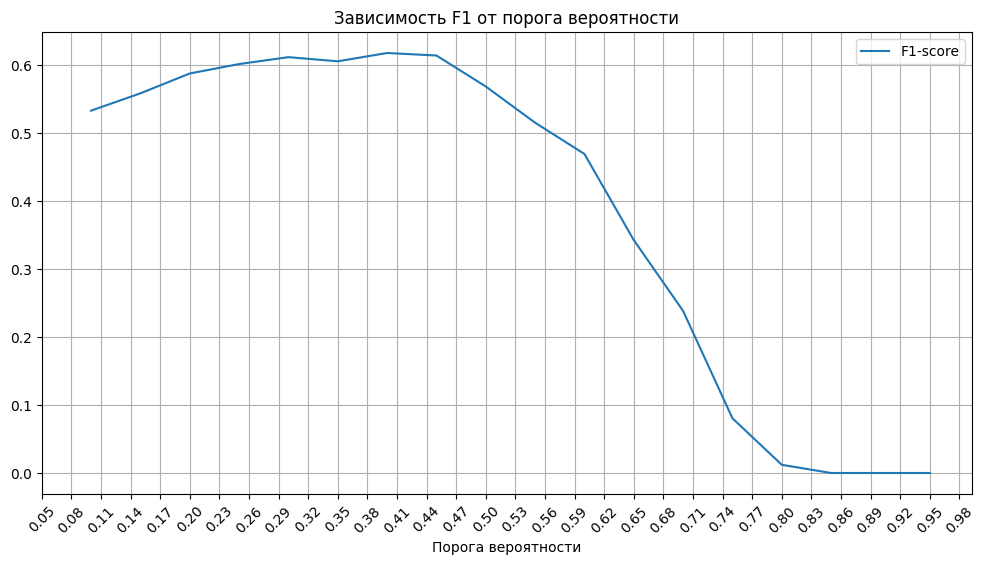

In [44]:
plt.figure(figsize=(12, 6))
plt.plot(thresholds, f1_scores, label='F1-score')

plt.title('Зависимость F1 от порога вероятности')
plt.xlabel('Порога вероятности')
plt.xticks(thresholds)
plt.xticks(np.arange(0.05, 1, 0.03), rotation=45)
plt.grid(True)
plt.legend()

In [45]:
best_threshold = thresholds[np.array(f1_scores).argmax()]
best_threshold

np.float64(0.40000000000000013)

In [46]:
best_model = SVC(kernel='rbf', C=1, class_weight={0:1, 1:3},
                 random_state=42, probability=True)

best_model.fit(X_train_scaled, y_train)
y_proba_test = best_model.predict_proba(X_test_scaled)[:, 1]

optimal_threshold = 0.4
y_pred_optimal = (y_proba_test >= optimal_threshold).astype(int)

print_metrics(y_test, y_pred_optimal, y_proba_test)

Accuracy:  0.7410
Precision: 0.5932
Recall:    0.6442
F1-score:  0.6176
ROC-AUC:   0.7719


**Вывод:** Порог 0.4 дал улучшение F1 с 0.6 до 0.6176 за счёт лучшего баланса Precision и Recall. Хотя Recall снизился (с 0.77 до 0.64), Precision выросла с 0.49 до 0.59, что сделало модель более сбалансированной.

## Часть IV. Калибровка

Переведем результаты модели в понятный бизнесу формат: вместо уверенности модели будем получать корректно интерпретируемые вероятности. Для этого выполним калибровку предсказаний.


### Задание 4.1*

**Выберите лучшую модель из предыдущих частей и выполните для нее калибровку:**
* Воспользуйтесь `CalibratedClassifierCV` из `sklearn`, в качестве способов калибровки попробуйте:
  * метод Платта;
  * изотоническую регрессию.
* Рассчитайте значение целевой метрики и метрики, не зависящей от порога, на каждой из выборок.
* Сравните качество модели до и после калибровки, а также между двумя методами калибровки.
* Сделайте вывод, ответив на вопрос: **«Стала ли модель лучше с точки зрения качества и интерпретируемости?»**

In [47]:
calibrated_model = CalibratedClassifierCV(
    best_model,
    method='sigmoid',
    cv=10
)

calibrated_model.fit(X_train_scaled, y_train)
y_train_pred_proba_platt = calibrated_model.predict_proba(X_train_scaled)[:, 1]
y_test_pred_proba_platt = calibrated_model.predict_proba(X_test_scaled)[:, 1]

In [48]:
y_train_pred_platt = calibrated_model.predict(X_train_scaled)
y_test_pred_platt = calibrated_model.predict(X_test_scaled)

print("TRAIN METRICS:")
print_metrics(y_train, y_train_pred_platt, y_train_pred_proba_platt)
print("\nTEST METRICS:")
print_metrics(y_test, y_test_pred_platt, y_test_pred_proba_platt)

TRAIN METRICS:
Accuracy:  0.8122
Precision: 0.7387
Recall:    0.6513
F1-score:  0.6922
ROC-AUC:   0.8586

TEST METRICS:
Accuracy:  0.7590
Precision: 0.6694
Recall:    0.5092
F1-score:  0.5784
ROC-AUC:   0.7715


In [49]:
def plot_calibration_curve(
    y_train, y_train_pred_proba_base, y_train_pred_proba_calib
):
    prob_true_base, prob_pred_base = calibration_curve(
        y_train, y_train_pred_proba_base, n_bins=10
    )

    prob_true_calib, prob_pred_calib = calibration_curve(
        y_train, y_train_pred_proba_calib, n_bins=10
    )

    plt.plot(prob_pred_base, prob_true_base, marker='o', label='Best')
    plt.plot(prob_pred_calib, prob_true_calib, marker='o', label='Calibrated')
    plt.plot([0, 1], [0, 1], '--', label='Perfect')

    plt.xlabel('Predicted probability')
    plt.ylabel('True probability')
    plt.legend()
    plt.show()

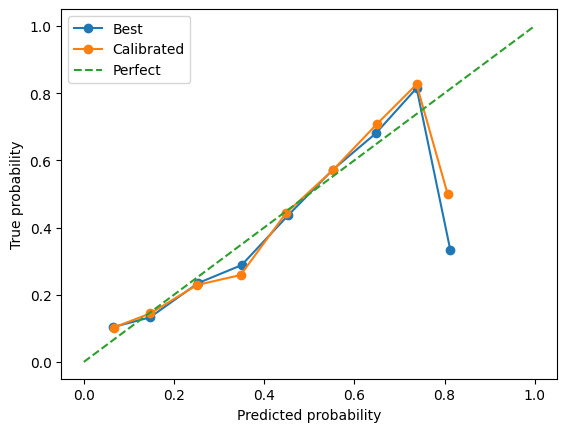

In [50]:
plot_calibration_curve(y_test, y_proba_test, y_test_pred_proba_platt)

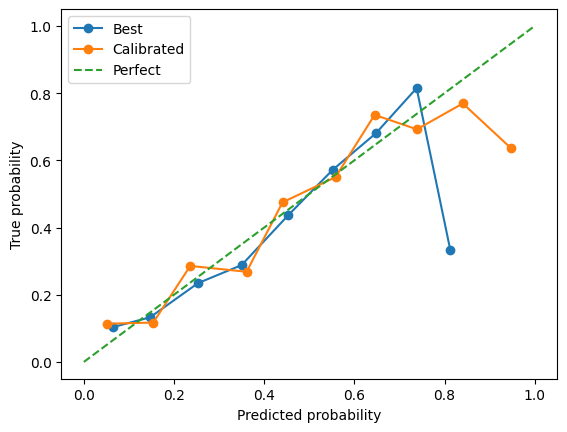

TRAIN METRICS:
Accuracy:  0.8132
Precision: 0.7430
Recall:    0.6482
F1-score:  0.6924
ROC-AUC:   0.8604

TEST METRICS:
Accuracy:  0.7550
Precision: 0.6613
Recall:    0.5031
F1-score:  0.5714
ROC-AUC:   0.7726


In [51]:
calibrated_model = CalibratedClassifierCV(
    best_model,
    method='isotonic',
    cv=10
)

calibrated_model.fit(X_train_scaled, y_train)
y_train_pred_proba_isotonic = calibrated_model.predict_proba(X_train_scaled)[:, 1]
y_test_pred_proba_isotonic = calibrated_model.predict_proba(X_test_scaled)[:, 1]

plot_calibration_curve(y_test, y_proba_test, y_test_pred_proba_isotonic)
y_train_pred_isotonic = calibrated_model.predict(X_train_scaled)
y_test_pred_isotonic = calibrated_model.predict(X_test_scaled)

print("TRAIN METRICS:")
print_metrics(y_train, y_train_pred_isotonic, y_train_pred_proba_isotonic)
print("\nTEST METRICS:")
print_metrics(y_test, y_test_pred_isotonic, y_test_pred_proba_isotonic)

**Вывод:** По качеству (целевая метрика F1):
Модель стала хуже — F1 упал с 0.62 до 0.57.

По интерпретируемости вероятностей:
Калибровка не дала значительного улучшения — вероятности остались почти такими же, как и были. График показывает, что обе модели одинаково отклоняются от идеальной диагонали.

Итог: Калибровка не улучшила модель. Исходная модель с порогом 0.4 остаётся лучшей по целевой метрике F1